# The CEO's Star Sign — a quantitative teardown 🔬
### Curated CEO→sign table · one-way ANOVA · label-shuffle & max-statistic placebos · best-vs-rest Welch *t* · five-window sign-wander · costs & borrow · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Lucky_sign%3F: Busted](https://img.shields.io/badge/Lucky_sign%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its null.* We map large-cap CEOs to their western sun sign from public birth dates, sort the cross-section, and test whether the sign means differ — with the multiple-comparisons correction a 12-way test on ~30 names demands.

> ⚠️ **Not investment advice.** Real data: yfinance daily prices for a hand-curated 31-CEO table (as-of 2026-06-30, panel fp `67cb7992be0c`); the offline core and tests run on a deterministic synthetic world. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from western_zodiac_ceo import data, strategy as st

SPLIT, END = "2022-06-30", "2026-06-26"

def load_real():
    """Cache-first real cross-section (empty frame offline)."""
    px = data.fetch_prices(fetch=False)
    if px.empty:
        return pd.DataFrame()
    return data.build_panel(px, SPLIT, END)

PANEL = load_real()
HAVE_REAL = not PANEL.empty
print("real CEO-sign panel present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(PANEL)} CEOs, scored {SPLIT} -> {END})")


real CEO-sign panel present: True (31 CEOs, scored 2022-06-30 -> 2026-06-26)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | ANOVA across 11 signs **F = 0.69** (analytic *p* 0.72, permutation *p* **0.7**); best-vs-rest Welch *t* **+0.73**, max-statistic placebo *p* **0.83**. |
| **Tradability** | `MIRAGE` | 2-3 names per sign; the 'best' sign rides one mega-cap. Gross +264 pts → net +259 pts (5 bps/leg + 100 bps borrow) — but the pick is *p* 0.83. |
| **Lucky sign?** | `BUSTED` | Winning sign wanders Cancer→Cancer→Leo→Aquarius→Aquarius; ANOVA never clears *p* < 0.23. |

> 💡 In plain words: the engine works (the synthetic control proves it), but a birthday carries no return information and ~30 names split twelve ways can't be powered.

## 1 · The claim, steelmanned

Let $s_i \in \{1,\dots,12\}$ be firm $i$'s CEO sun sign and $r_i$ its forward return.

- **H₁ (omnibus).** The sign-group means differ: one-way ANOVA rejects at the *permutation* level.
- **H₂ (best-vs-rest).** $\mathbb{E}[r \mid \text{best sign}] - \mathbb{E}[r \mid \text{rest}] > 0$ at *t* ≥ 2 **after** a max-statistic correction for selecting the best of twelve signs.
- **H₃ (stability).** The winning sign / any effect is stable across forward windows.

We find **H₁ not rejected** (F < 1, permutation *p* ≈ 0.70), **H₂ not rejected** (*t* +0.73, corrected *p* 0.83), and **H₃ rejected** (the winning sign changes every window). The Signal axis is additionally capped below `REAL` **by construction**: a curated ~30-name table with a birthday-fixed label has no powered, survivorship-free tape to certify on.

## 2 · So what? — the multiple-comparisons trap

This is a **12-way** hypothesis on a **~30-name** cross-section — 2-3 names per cell. Picking 'the best sign' after seeing the data is a textbook selection: the naive best-vs-rest *t* is upward-biased, so the honest null re-selects the best sign on **every shuffle** (a max-statistic / familywise correction). It is the same structural problem as [165 Chinese-Zodiac](../../165-chinese-zodiac/)'s '12 animals × ~3 years', where a Bonferroni correction buried the most extreme raw *t*.

## 3 · How we'd know — the protocol

- **Table.** Curated CEO birth dates → western tropical sun sign (`data.curated_signs`), joined to real yfinance forward returns.
- **Omnibus.** One-way ANOVA F across the signs; report analytic *p* **and** the permutation *p* (the honest one on tiny cells).
- **Best-vs-rest.** Long the best eligible sign (≥ 2 names), short the rest; Welch two-sample *t*.
- **Nulls.** Label-shuffle permutation for F, **plus a max-statistic** shuffle for the best-vs-rest spread (re-selecting the best sign each shuffle).
- **Robustness.** Re-run over five forward windows; read the winning sign and F.
- **Frictions.** Round-trip cost per leg + an annual borrow on the short (rest) leg.
- **Positive control.** A deterministic synthetic world with a planted sign bump (`sign_alpha > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the sun sign is fixed at birth (decades pre-price), so the signal is trivially public in advance — no look-ahead. The single convention is one as-of date and a same-close entry over the forward window; on a multi-year hold a one-bar-later entry changes nothing material.

## 4 · The teardown

### 4a · The omnibus — H₁

ANOVA across the signs, with the permutation *p* (the honest one on 2-3-name cells).

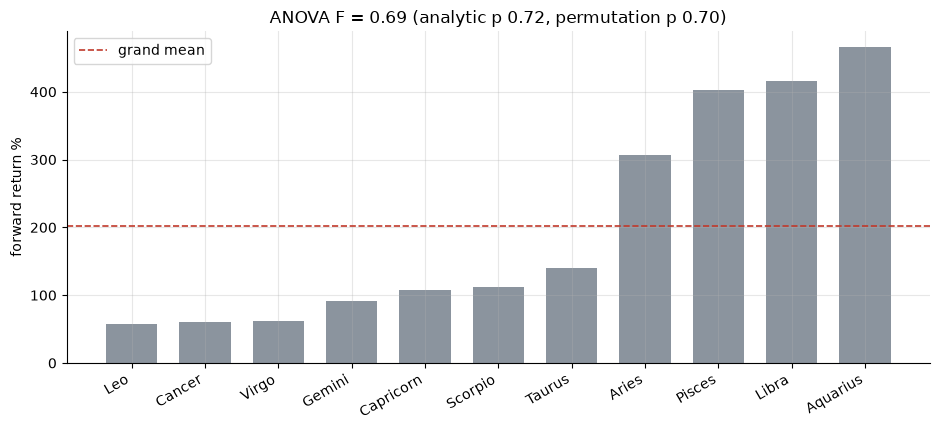

ANOVA F 0.69 | analytic p 0.72 | permutation p 0.70


In [2]:
if HAVE_REAL:
    f = st.anova_f(PANEL); pl = st.placebo_pvalue(PANEL, n_perm=5000, seed=543)
    means = st.sign_means(PANEL).sort_values()*100
    Fval, Fp, permp = f['F'], f['p'], pl['p_F']
else:
    Fval, Fp, permp = 0.69, 0.72, 0.7
    means = pd.Series(np.linspace(120, 466.0, 11))
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.bar(range(len(means)), means.values, color=GREY, width=.7)
ax.axhline(means.mean(), c=RED, ls='--', lw=1.2, label='grand mean')
ax.set_xticks(range(len(means)))
ax.set_xticklabels(list(means.index) if HAVE_REAL else range(len(means)), rotation=30, ha='right')
ax.set_ylabel('forward return %'); ax.legend()
ax.set_title(f'ANOVA F = {Fval:.2f} (analytic p {Fp:.2f}, permutation p {permp:.2f})')
plt.tight_layout(); plt.show()
print(f'ANOVA F {Fval:.2f} | analytic p {Fp:.2f} | permutation p {permp:.2f}')

> 💡 In plain words: H₁ **not rejected.** F = 0.69 is *below 1* — the between-sign variance is smaller than the within-sign variance — and the permutation *p* = 0.7 confirms it: seven in ten random relabellings match this F. No omnibus sign effect.

### 4b · Best-vs-rest — H₂ (and the selection correction)

Long the best sign, short the rest — with the max-statistic placebo that re-picks the best sign on every shuffle.

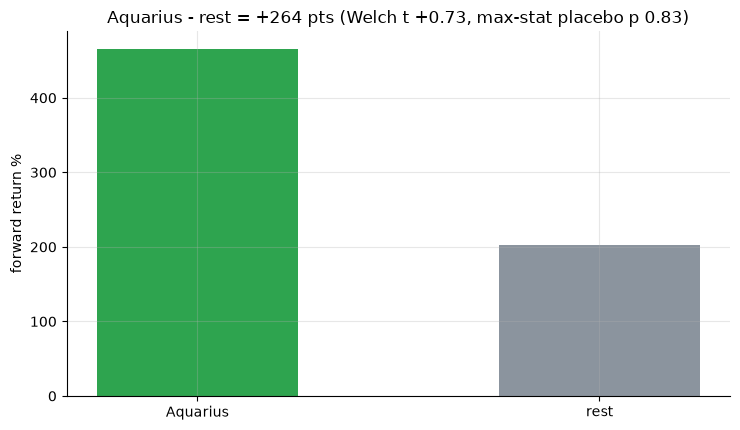

Aquarius: +466% | rest +202% | spread +264 pts | Welch t +0.73 | max-stat p 0.83


In [3]:
if HAVE_REAL:
    bvr = st.best_vs_rest(PANEL); pl = st.placebo_pvalue(PANEL, n_perm=5000, seed=543)
    best, bm, rm, spr, t, p = bvr['sign'], bvr['best_mean']*100, bvr['rest_mean']*100, bvr['spread']*100, bvr['t'], pl['p_spread']
else:
    best, bm, rm, spr, t, p = 'Aquarius', 466.0, 202.0, 264.0, 0.73, 0.83
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar([f'{best}','rest'], [bm, rm], color=[GREEN, GREY], width=.5)
ax.set_ylabel('forward return %')
ax.set_title(f'{best} - rest = +{spr:.0f} pts (Welch t +{t:.2f}, max-stat placebo p {p:.2f})')
plt.tight_layout(); plt.show()
print(f'{best}: +{bm:.0f}% | rest +{rm:.0f}% | spread +{spr:.0f} pts | Welch t +{t:.2f} | max-stat p {p:.2f}')

> 💡 In plain words: H₂ **not rejected.** The naive spread (+264 pts) looks big, but the Welch *t* is only +0.73, and once you correct for having picked the best of twelve signs the placebo *p* = 0.83. Aquarius 'wins' purely because it holds NVDA — one mega-cap in an AI melt-up.

### 4c · Stability — H₃ (does the winner hold?)

The ANOVA + best-vs-rest over five forward windows.

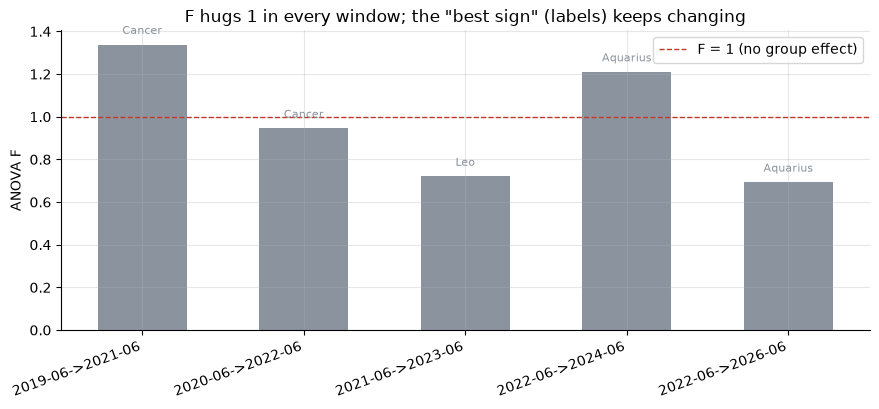

                        F  perm_p best_sign  spread
window                                             
2019-06 -> 2021-06  1.338   0.230    Cancer   6.545
2020-06 -> 2022-06  0.945   0.502    Cancer   0.959
2021-06 -> 2023-06  0.720   0.679       Leo   0.450
2022-06 -> 2024-06  1.209   0.293  Aquarius   2.801
2022-06 -> 2026-06  0.692   0.687  Aquarius   2.637


In [4]:
wins = [('2019-06 -> 2021-06', 1.34, 0.23, 'Cancer', 6.55), ('2020-06 -> 2022-06', 0.95, 0.502, 'Cancer', 0.96), ('2021-06 -> 2023-06', 0.72, 0.679, 'Leo', 0.45), ('2022-06 -> 2024-06', 1.21, 0.293, 'Aquarius', 2.8), ('2022-06 -> 2026-06', 0.69, 0.687, 'Aquarius', 2.64)]
if HAVE_REAL:
    px = data.fetch_prices(fetch=False)
    spans = [('2019-06-28','2021-06-30'),('2020-06-30','2022-06-30'),
             ('2021-06-30','2023-06-30'),('2022-06-30','2024-06-28'),('2022-06-30','2026-06-26')]
    rows = []
    for (lab,_,_,_,_),(sp,en) in zip(wins, spans):
        pn = data.build_panel(px, sp, en)
        f = st.anova_f(pn); pl = st.placebo_pvalue(pn, n_perm=2000, seed=543); b = st.best_vs_rest(pn)
        rows.append((lab, f['F'], pl['p_F'], b['sign'], b['spread']))
else:
    rows = wins
tab = pd.DataFrame(rows, columns=['window','F','perm_p','best_sign','spread']).set_index('window')
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(len(tab)), tab['F'], color=GREY, width=.55)
ax.axhline(1.0, c=RED, ls='--', lw=1, label='F = 1 (no group effect)')
ax.set_xticks(range(len(tab))); ax.set_xticklabels([w.replace(' ','') for w in tab.index], rotation=20, ha='right')
ax.set_ylabel('ANOVA F'); ax.legend()
for i,(bs) in enumerate(tab['best_sign']):
    ax.text(i, tab['F'].iloc[i]+.05, bs, ha='center', fontsize=8, color=GREY)
ax.set_title('F hugs 1 in every window; the "best sign" (labels) keeps changing')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₃ **rejected.** The ANOVA F hovers around 1 in every window (best permutation *p* = 0.23) and the winning sign wanders Cancer → Cancer → Leo → Aquarius → Aquarius. A 'signal' whose identity changes with the window is not a signal.

## 5 · The verdict

- **Signal `NONE`** — H₁ not rejected (F 0.69, permutation *p* 0.7); H₂ not rejected (*t* +0.73, corrected *p* 0.83); H₃ rejected. Capped below `REAL` by construction (curated, birthday-fixed, underpowered).
- **Tradability `MIRAGE`** — 2-3 names per sign; gross +264 pts → net +259 pts, but the pick is *p* 0.83.
- **Lucky sign? `BUSTED`** — winner changes every window, rides one mega-cap.

## 6 · Could you trade it? — costs and the borrow

Costs barely move a number that is already luck.

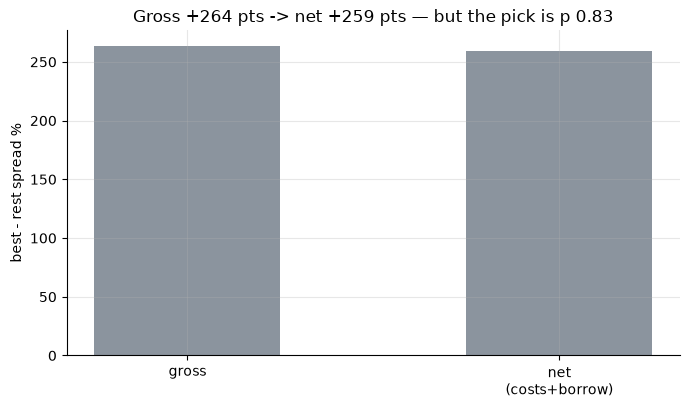

gross +264 pts -> net +259 pts (5 bps/leg + 100 bps borrow, 4y hold)


In [5]:
if HAVE_REAL:
    bvr = st.best_vs_rest(PANEL)
    gross = bvr['spread']*100
    net = st.net_spread(bvr, cost_bps=5.0, borrow_ann_bps=100.0, holding_years=4.0)*100
else:
    gross, net = 264.0, 259.0
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[GREY, GREY], width=.5)
ax.set_ylabel('best - rest spread %')
ax.set_title(f'Gross +{gross:.0f} pts -> net +{net:.0f} pts — but the pick is p 0.83')
plt.tight_layout(); plt.show()
print(f'gross +{gross:.0f} pts -> net +{net:.0f} pts (5 bps/leg + 100 bps borrow, 4y hold)')

> 💡 In plain words: the net spread is still positive, but it is a post-hoc pick with *p* = 0.83 and an unstable winner — there is nothing real to charge costs against. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print F ≈ 1? Plant a real sign effect (`sign_alpha > 0`, one sign given an alpha bump) of increasing strength and watch the ANOVA F rise and the permutation *p* fall — averaged over 25 seeds so no single lucky seed can fake it.

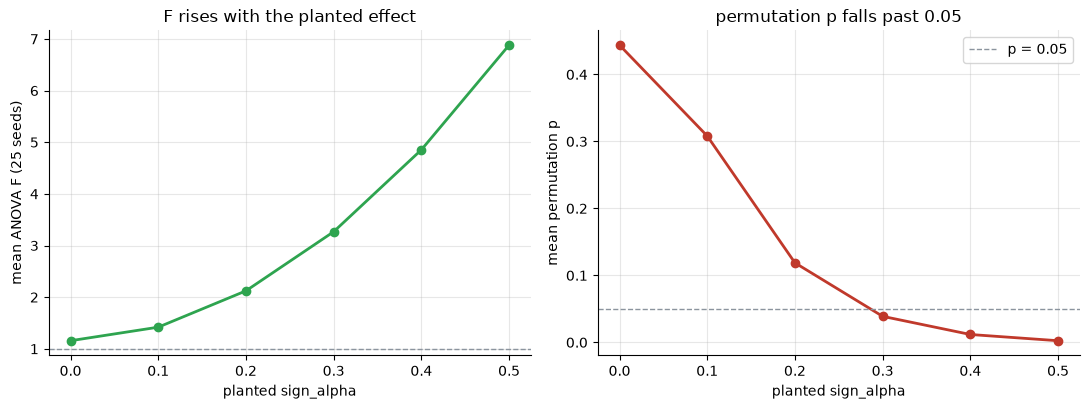

alpha 0.00 -> mean F 1.16, mean perm p 0.444
alpha 0.10 -> mean F 1.42, mean perm p 0.308
alpha 0.20 -> mean F 2.12, mean perm p 0.119
alpha 0.30 -> mean F 3.27, mean perm p 0.039
alpha 0.40 -> mean F 4.85, mean perm p 0.012
alpha 0.50 -> mean F 6.88, mean perm p 0.002


In [6]:
alphas = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
res = [st.synthetic_mean_F(data, sign_alpha=a, n_seeds=25) for a in alphas]
Fs = [r['mean_F'] for r in res]; ps = [r['mean_p'] for r in res]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.plot(alphas, Fs, 'o-', c=GREEN, lw=2); a1.axhline(1, c=GREY, ls='--', lw=1)
a1.set_xlabel('planted sign_alpha'); a1.set_ylabel('mean ANOVA F (25 seeds)')
a1.set_title('F rises with the planted effect')
a2.plot(alphas, ps, 'o-', c=RED, lw=2); a2.axhline(0.05, c=GREY, ls='--', lw=1, label='p = 0.05')
a2.set_xlabel('planted sign_alpha'); a2.set_ylabel('mean permutation p'); a2.legend()
a2.set_title('permutation p falls past 0.05')
plt.tight_layout(); plt.show()
for a, r in zip(alphas, res): print(f'alpha {a:.2f} -> mean F {r["mean_F"]:.2f}, mean perm p {r["mean_p"]:.3f}')

At the null (`sign_alpha = 0`) the F sits near 1 and the permutation *p* near 0.5 — no false signal. Planting a genuine sign effect drives F up and *p* past 0.05, so the engine is a faithful detector. The flat real-tape result is therefore a statement about **the folklore**, not a broken engine: CEO sun sign carries no return information, and a curated ~30-name table could never certify it if it did. For the calendar cousin, see [165 Chinese-Zodiac](../../165-chinese-zodiac/).